## Channel storage and discharge experiments

This notebook tests BMI state editing in PCR-GLOBWB.

Main question:
- What happens when `channel_storage` is changed through `set_value`?


Workflow:
- Build the model setup and forcing objects.
- Run a baseline `get_value` experiment.
- Run a `set_value(channel_storage)` experiment.
- Compare model output and observations.

The commented cells near the end are historical experiments kept as reference.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from rich import print
from tqdm.notebook import tqdm

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage

PROJECT_ROOT = Path().resolve().parents[2]
sys.path.append(str(PROJECT_ROOT))

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [33]:
STATIONS_PCR
STATIONS_TO_PLOT = ["Chatly", "Kerki"]

In [3]:
pcr_glob_directory = PCR_GLOBAL_PARAMS
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL

parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "calibrated_best_save_QS.ini",
    target_model="pcrglobwb",
    supported_model_versions={"25mar"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [4]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_25mar.sif")
my_image.version

'25mar'

In [5]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

reference_2x = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

reference_multiple = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
) 

reference_wave = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)   




In [6]:
experiment_start_date = "1949-11-01T00:00:00Z"
experiment_end_date = "1950-12-30T00:00:00Z"

In [7]:
from pathlib import Path
import shutil

for cfg_dir in [Path("channel_experiment_reference"),
    Path("channel_experiment_set_storage"),
    Path("channel_experiment_set_multiple_storage"),
    Path("channel_experiment_set_wave_storage")]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0, cfg_dir="channel_experiment_reference"
)


reference_2x_config, reference_2x_dir = reference_2x.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0, cfg_dir="channel_experiment_set_storage"
)


reference_multiple_config, reference_multiple_dir = reference_multiple.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0, cfg_dir="channel_experiment_set_multiple_storage"
)

reference_wave_config, reference_wave_dir = reference_wave.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0, cfg_dir="channel_experiment_set_wave_storage"
)


In [8]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1949-11-01T00:00:00Z'), ('end_time', '1950-12-30T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 424

In [9]:
# Before loop
MODELS = {
    "reference": reference,
    "reference_2x": reference_2x,
    "reference_multiple": reference_multiple,
    "reference_wave": reference_wave,
}

station_records = {
    model_name: {
        station: {"discharge": [], "channel_storage": []}
        for station in STATIONS_PCR
    }
    for model_name in MODELS
}

In [10]:
reference.initialize(reference_config)
reference_2x.initialize(reference_2x_config)
reference_multiple.initialize(reference_multiple_config)
reference_wave.initialize(reference_wave_config)

In [11]:
lat_idx = 61
lon_idx = 127

coords_3 = [
    (61, 127),
    (61, 128),
    (60, 128),
    (59, 129),
    (59, 130),
    (58, 131),
    (62, 126),
    (62, 125),
    (63, 124),
    (63, 123),
    (63, 122),
    (63, 121)
]



In [12]:
DAILY_REMOVAL_TARGET = 10 * 1e9 / 365   #10  cubic kilometers per year converted to cubic meters per day



history_2x = []
history_multiple = []
history_wave = []
timestamps = []

for i in tqdm(range(number_of_days), desc="Running model"):
    reference.update()
    reference_2x.update()
    reference_multiple.update()
    reference_wave.update()

    current_time = pd.to_datetime(reference.time_as_isostr)
    timestamps.append(current_time)

    for model_name, model in MODELS.items():
        for station_name, coords in STATIONS_PCR.items():
            discharge = model.get_value_at_coords(
                "discharge",
                lat=[coords["lat"]],
                lon=[coords["lon"]],
            )
            channel_storage = model.get_value_at_coords(
                "channel_storage",
                lat=[coords["lat"]],
                lon=[coords["lon"]],
            )
            station_records[model_name][station_name]["discharge"].append(float(discharge[0]))
            station_records[model_name][station_name]["channel_storage"].append(float(channel_storage[0]))



    # --- 1. Perturb reference_2x (Single cell) ---
    test_variable = reference_2x.get_value_as_xarray("channel_storage")
    test_values = test_variable.values.copy()
    
    old_value = test_values[lat_idx, lon_idx]
    
    if old_value > 0:
        # Calculate factor to leave behind (Old - Target) / Old
        calculated_factor = (old_value - DAILY_REMOVAL_TARGET) / old_value
    else:
        calculated_factor = 1.0
        
    # Bound the factor between 0.2 (max 80% removal) and 1.0 (0% removal)
    dynamic_factor_2x = np.clip(calculated_factor, 0.2, 1.0)
    
    # Apply and track exactly how much was actually taken
    test_values[lat_idx, lon_idx] *= dynamic_factor_2x
    amount_changed_2x = test_values[lat_idx, lon_idx] - old_value
    
    history_2x.append(amount_changed_2x)
    reference_2x.set_value("channel_storage", test_values.flatten())


    # --- 2. Perturb reference_multiple (Multiple cells) ---
    test_variable_multiple = reference_multiple.get_value_as_xarray("channel_storage")
    test_values_multiple = test_variable_multiple.values.copy()
    
    # For multiple cells, let's divide the 10,000 target equally among all active points
    # (Alternatively, you could pull 10,000 from EACH cell by omitting the division)
    target_per_cell = DAILY_REMOVAL_TARGET / len(coords_3)
    
    timestep_multiple_changes = {}
    for l_idx, m_idx in coords_3:
        old_val_m = test_values_multiple[l_idx, m_idx]
        
        if old_val_m > 0:
            calculated_m_factor = (old_val_m - target_per_cell) / old_val_m
        else:
            calculated_m_factor = 1.0
            
        dynamic_factor_m = np.clip(calculated_m_factor, 0.2, 1.0)
        
        test_values_multiple[l_idx, m_idx] *= dynamic_factor_m
        diff_m = test_values_multiple[l_idx, m_idx] - old_val_m
        
        timestep_multiple_changes[(l_idx, m_idx)] = diff_m
        
    history_multiple.append(timestep_multiple_changes)
    reference_multiple.set_value("channel_storage", test_values_multiple.flatten())

    # --- 3. Perturb reference_wave (Multiple cells, seasonal) ---
    test_variable_wave = reference_wave.get_value_as_xarray("channel_storage")
    test_values_wave = test_variable_wave.values.copy()

    doy = current_time.day_of_year
    seasonal_target = (1 - np.cos(2 * np.pi * (doy - 1) / 365)) * DAILY_REMOVAL_TARGET
    target_per_cell_wave = seasonal_target / len(coords_3)

    timestep_wave_changes = {}
    for l_idx, m_idx in coords_3:
        old_val_w = test_values_wave[l_idx, m_idx]

        if old_val_w > 0:
            calculated_w_factor = (old_val_w - target_per_cell_wave) / old_val_w
        else:
            calculated_w_factor = 1.0

        dynamic_factor_w = np.clip(calculated_w_factor, 0.2, 1.0)

        test_values_wave[l_idx, m_idx] *= dynamic_factor_w
        diff_w = test_values_wave[l_idx, m_idx] - old_val_w

        timestep_wave_changes[(l_idx, m_idx)] = diff_w

    history_wave.append(timestep_wave_changes)
    reference_wave.set_value("channel_storage", test_values_wave.flatten())

print("Model run finished!")

Running model:   0%|          | 0/424 [00:00<?, ?it/s]

Model run finished!

In [30]:
# ==========================================
# 1. Export Single Cell Data (history_2x)
# ==========================================
# Ensure timestamps are uniform datetime64 
datetime_timestamps = np.array([t.tz_localize(None) if hasattr(t, 'tz_localize') else t for t in timestamps], dtype="datetime64[ns]")

ds_2x = xr.Dataset(
    data_vars={
        "storage_change": ("time", history_2x)
    },
    coords={
        "time": datetime_timestamps
    }
)
ds_2x.storage_change.attrs["units"] = "same as model"
ds_2x.to_netcdf("history_single_cell.nc")


# ==========================================
# 2. Export Multiple Cell Data (history_multiple)
# ==========================================
# Extract unique sorted latitudes and longitudes to build a real spatial grid
unique_lats = sorted(list(set(c[0] for c in coords_3)))
unique_lons = sorted(list(set(c[1] for c in coords_3)))

# Create a proper 3D grid: shape (time, lat, lon)
grid_data = np.zeros((len(datetime_timestamps), len(unique_lats), len(unique_lons)))

# Map coordinates to their respective index positions for fast lookup
lat_map = {lat: i for i, lat in enumerate(unique_lats)}
lon_map = {lon: i for i, lon in enumerate(unique_lons)}

# Populate the grid
for t_idx, daily_dict in enumerate(history_multiple):
    for coord, value in daily_dict.items():
        if coord in coords_3:  # Only map coordinates we care about
            lat_idx = lat_map[coord[0]]
            lon_idx = lon_map[coord[1]]
            grid_data[t_idx, lat_idx, lon_idx] = value

# Build the structured Xarray Dataset
ds_multiple = xr.Dataset(
    data_vars={
        "storage_change": (["time", "lat", "lon"], grid_data)
    },
    coords={
        "time": datetime_timestamps,
        "lat": unique_lats,
        "lon": unique_lons
    }
)

ds_multiple.storage_change.attrs["units"] = "same as model"


# Save once, safely
try:
    ds_multiple.to_netcdf("history_multiple_cells.nc")
except Exception as e:
    print(f"Failed to save NetCDF file: {e}")



# ==========================================
# 3. Export Wave Cell Data (history_wave)
# ==========================================
grid_data_wave = np.zeros((len(datetime_timestamps), len(unique_lats), len(unique_lons)))

for t_idx, daily_dict in enumerate(history_wave):
    for coord, value in daily_dict.items():
        if coord in coords_3:
            lat_i = lat_map[coord[0]]
            lon_i = lon_map[coord[1]]
            grid_data_wave[t_idx, lat_i, lon_i] = value

ds_wave = xr.Dataset(
    data_vars={
        "storage_change": (["time", "lat", "lon"], grid_data_wave)
    },
    coords={
        "time": datetime_timestamps,
        "lat": unique_lats,
        "lon": unique_lons
    }
)
ds_wave.storage_change.attrs["units"] = "same as model"

try:
    ds_wave.to_netcdf("history_wave_cells.nc")
except Exception as e:
    print(f"Failed to save NetCDF file: {e}")




In [31]:
for model_name, stations in station_records.items():
    ds = xr.Dataset(
        data_vars={
            f"{station}_{var}": ("time", values)
            for station, vars_dict in stations.items()
            for var, values in vars_dict.items()
        },
        coords={"time": datetime_timestamps}
    )
    ds.to_netcdf(f"station_timeseries_{model_name}.nc")


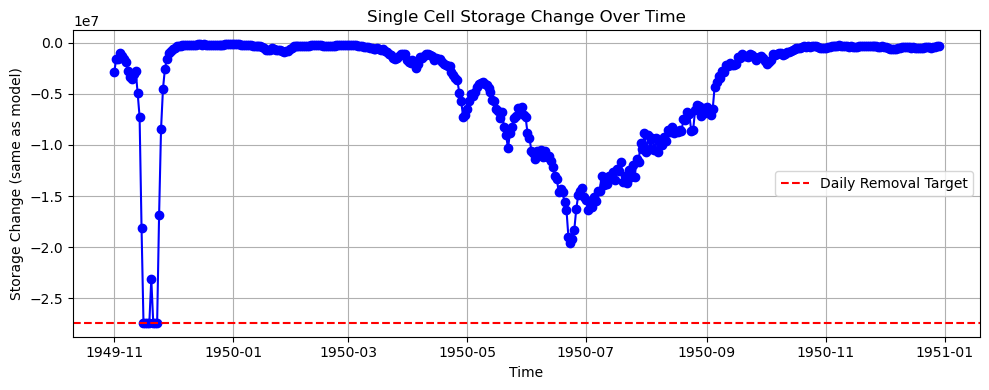

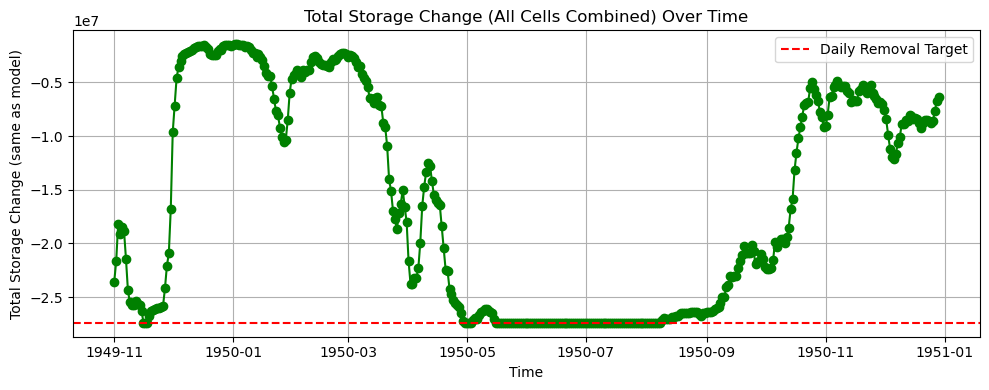

In [15]:
# ==========================================
# 1. Plot Single Cell Data (Time Series)
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(ds_2x["time"], ds_2x["storage_change"], marker="o", color="b", linestyle="-")
plt.title("Single Cell Storage Change Over Time")
plt.xlabel("Time")
plt.ylabel(f"Storage Change ({ds_2x['storage_change'].attrs.get('units', 'same as model')})")
plt.axhline(y=-DAILY_REMOVAL_TARGET, color="r", linestyle="--", label="Daily Removal Target")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 2. Plot Multiple Cell Data (Total Over Time)
# ==========================================
# Sum up the storage change across all latitudes and longitudes for each time step
total_storage_change = ds_multiple["storage_change"].sum(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
plt.plot(ds_multiple["time"], total_storage_change, marker="o", color="g", linestyle="-")
plt.title("Total Storage Change (All Cells Combined) Over Time")
plt.xlabel("Time")
plt.ylabel(f"Total Storage Change ({ds_multiple['storage_change'].attrs.get('units', 'same as model')})")
plt.axhline(y=-DAILY_REMOVAL_TARGET, color="r", linestyle="--", label="Daily Removal Target")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

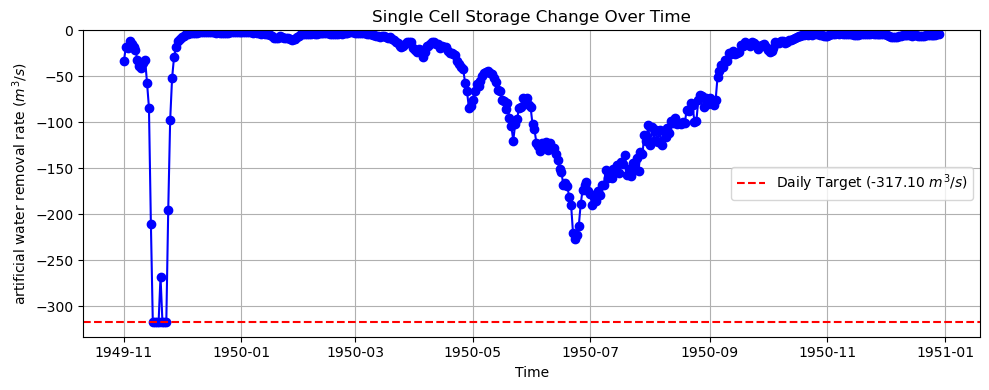

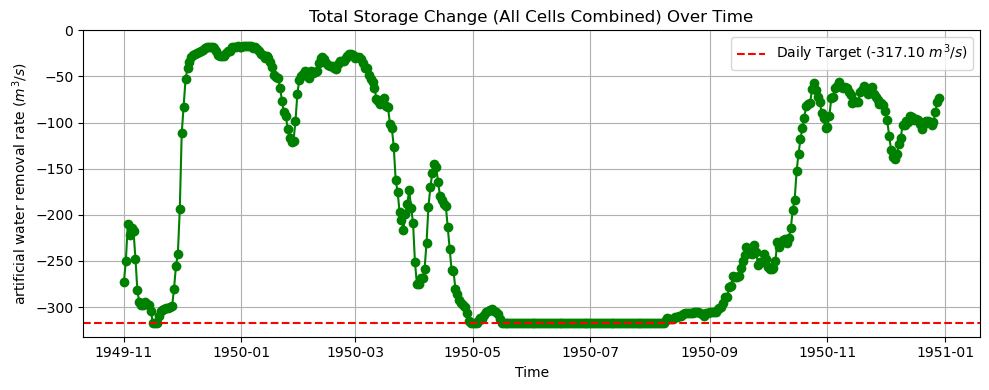

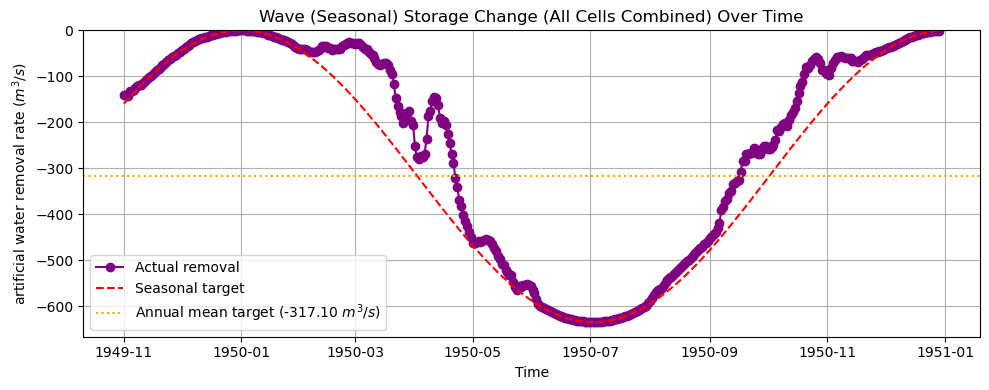

In [22]:


# ==========================================
# 0. Conversion Constants
# ==========================================
TOTAL_ANNUAL_M3 = 10e9
SECONDS_IN_YEAR = 365 * 24 * 3600
SECONDS_IN_DAY = 24 * 3600



# Continuous target in m3/s (~317.10 m3/s)
TARGET_M3_S = TOTAL_ANNUAL_M3 / SECONDS_IN_YEAR

# Convert dataset storage change from daily volume (m3/day) to flow rate (m3/s)
# (Adjust this conversion if your raw data is in a different unit like km3)
ds_2x_m3s = ds_2x["storage_change"] / SECONDS_IN_DAY
ds_multiple_m3s = ds_multiple["storage_change"] / SECONDS_IN_DAY

ylabel = f"artificial water removal rate ($m^3/s$)"
# ==========================================
# 1. Plot Single Cell Data (Time Series)
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(ds_2x["time"], ds_2x_m3s, marker="o", color="b", linestyle="-")
plt.title("Single Cell Storage Change Over Time")
plt.xlabel("Time")
plt.ylabel(ylabel)

# Drawing the target line in m3/s
plt.axhline(y=-TARGET_M3_S, color="r", linestyle="--", label=f"Daily Target (-{TARGET_M3_S:.2f} $m^3/s$)")

plt.ylim(top=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 2. Plot Multiple Cell Data (Total Over Time)
# ==========================================
# Sum up the converted storage change across all latitudes and longitudes for each time step
total_storage_change_m3s = ds_multiple_m3s.sum(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
plt.plot(ds_multiple["time"], total_storage_change_m3s, marker="o", color="g", linestyle="-")
plt.title("Total Storage Change (All Cells Combined) Over Time")
plt.xlabel("Time")
plt.ylabel(ylabel)

# Drawing the target line in m3/s
plt.axhline(y=-TARGET_M3_S, color="r", linestyle="--", label=f"Daily Target (-{TARGET_M3_S:.2f} $m^3/s$)")

plt.ylim(top=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 3. Plot Wave Cell Data (Total Over Time)
# ==========================================
ds_wave_m3s = ds_wave["storage_change"] / SECONDS_IN_DAY
total_storage_change_wave_m3s = ds_wave_m3s.sum(dim=["lat", "lon"])

# Compute the seasonal target curve in m3/s for reference
doys = np.arange(1, 366)
seasonal_curve_m3s = (1 - np.cos(2 * np.pi * (doys - 1) / 365)) * (TOTAL_ANNUAL_M3 / 365) / SECONDS_IN_DAY

plt.figure(figsize=(10, 4))
plt.plot(ds_wave["time"], total_storage_change_wave_m3s, marker="o", color="purple", linestyle="-", label="Actual removal")
doys = np.array([pd.Timestamp(t).day_of_year for t in ds_wave["time"].values])
seasonal_curve_m3s = (1 - np.cos(2 * np.pi * (doys - 1) / 365)) * (TOTAL_ANNUAL_M3 / 365) / SECONDS_IN_DAY

plt.plot(ds_wave["time"], -seasonal_curve_m3s, color="r", linestyle="--", label="Seasonal target")
plt.axhline(y=-TARGET_M3_S, color="orange", linestyle=":", label=f"Annual mean target (-{TARGET_M3_S:.2f} $m^3/s$)")
plt.title("Wave (Seasonal) Storage Change (All Cells Combined) Over Time")
plt.xlabel("Time")
plt.ylabel(ylabel)
plt.ylim(top=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

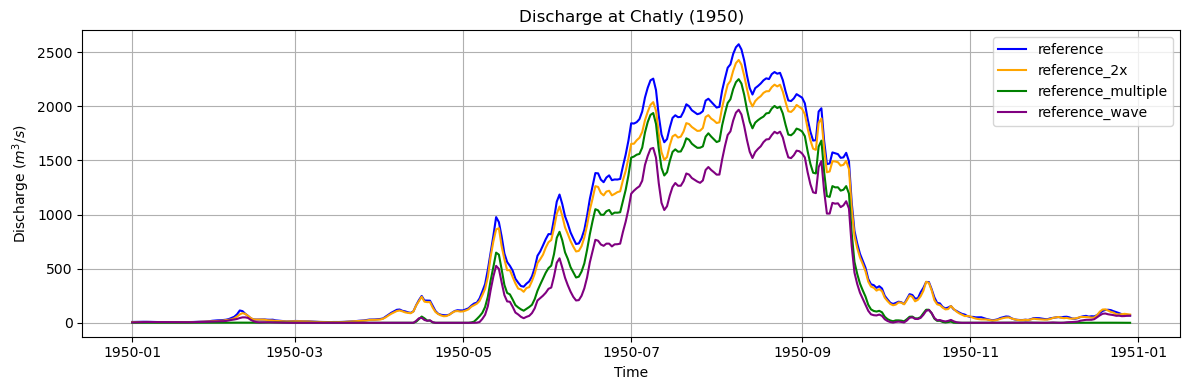

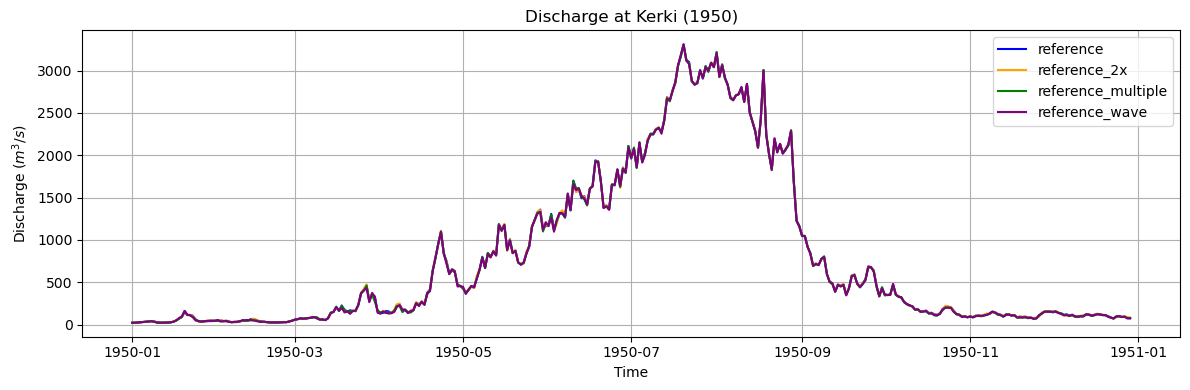

In [40]:
period_year = 1950

for station in STATIONS_TO_PLOT:
    plt.figure(figsize=(12, 4))
    
    for model_name in MODELS:
        ds = xr.open_dataset(f"station_timeseries_{model_name}.nc")
        ds_period = ds.sel(time=ds["time"].dt.year == period_year)
        plt.plot(
            ds_period["time"],
            ds_period[f"{station}_discharge"],
            color=MODEL_COLORS[model_name],
            label=model_name,
            linewidth=1.5
        )
        ds.close()
    
    plt.title(f"Discharge at {station} ({period_year})")
    plt.xlabel("Time")
    plt.ylabel("Discharge ($m^3/s$)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

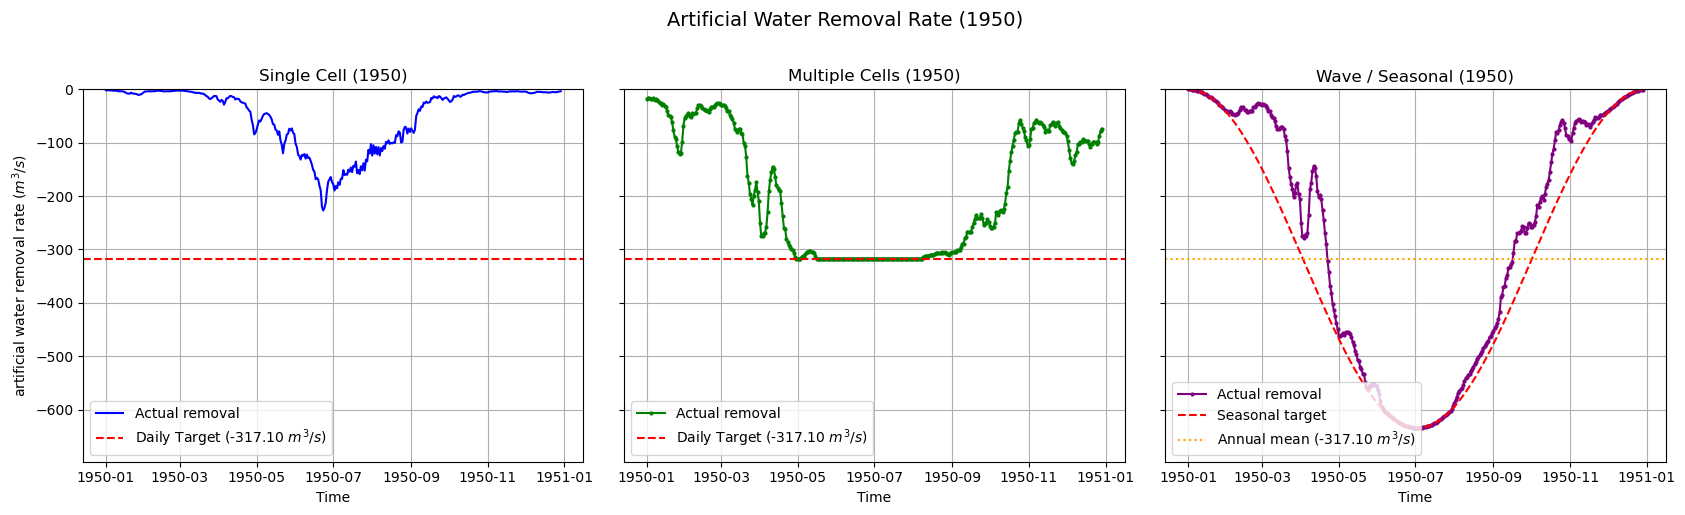

In [39]:
YEAR_TO_PLOT = 1950

# Filter all datasets to selected year
ds_2x_year = ds_2x_m3s.sel(time=ds_2x_m3s.time.dt.year == YEAR_TO_PLOT)
ds_multiple_year = total_storage_change_m3s.sel(time=total_storage_change_m3s.time.dt.year == YEAR_TO_PLOT)
ds_wave_year = total_storage_change_wave_m3s.sel(time=total_storage_change_wave_m3s.time.dt.year == YEAR_TO_PLOT)
seasonal_curve_year = seasonal_curve_m3s[ds_wave_m3s.time.dt.year.values == YEAR_TO_PLOT]

# Compute shared y limit from the most negative value across all three
ymin = min(
    float(ds_2x_year.min()),
    float(ds_multiple_year.min()),
    float(ds_wave_year.min()),
    -TARGET_M3_S
) * 1.1  # 10% padding

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

# ---- 1. Single Cell ----
axes[0].plot(ds_2x_year.time, ds_2x_year, color="b", linestyle="-", label="Actual removal")
axes[0].axhline(y=-TARGET_M3_S, color="r", linestyle="--", label=f"Daily Target (-{TARGET_M3_S:.2f} $m^3/s$)")
axes[0].set_title(f"Single Cell ({YEAR_TO_PLOT})")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(ylabel)
axes[0].set_ylim(bottom=ymin, top=0)
axes[0].grid(True)
axes[0].legend(loc="lower left")

# ---- 2. Multiple Cells ----
axes[1].plot(ds_multiple_year.time, ds_multiple_year, marker="o", color="g", linestyle="-", markersize=2,label="Actual removal")
axes[1].axhline(y=-TARGET_M3_S, color="r", linestyle="--", label=f"Daily Target (-{TARGET_M3_S:.2f} $m^3/s$)")
axes[1].set_title(f"Multiple Cells ({YEAR_TO_PLOT})")
axes[1].set_xlabel("Time")
axes[1].set_ylim(bottom=ymin, top=0)
axes[1].grid(True)
axes[1].legend(loc="lower left")

# ---- 3. Wave (Seasonal) ----
axes[2].plot(ds_wave_year.time, ds_wave_year, marker="o", color="purple", linestyle="-", markersize=2, label="Actual removal")
axes[2].plot(ds_wave_year.time, -seasonal_curve_year, color="r", linestyle="--", label="Seasonal target")
axes[2].axhline(y=-TARGET_M3_S, color="orange", linestyle=":", label=f"Annual mean (-{TARGET_M3_S:.2f} $m^3/s$)")
axes[2].set_title(f"Wave / Seasonal ({YEAR_TO_PLOT})")
axes[2].set_xlabel("Time")
axes[2].set_ylim(bottom=ymin, top=0)
axes[2].grid(True)
axes[2].legend(loc="lower left")

plt.suptitle(f"Artificial Water Removal Rate ({YEAR_TO_PLOT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# ==========================================
# Annual Totals for Selected Year
# ==========================================
total_2x_m3 = float(ds_2x_year.sum()) * SECONDS_IN_DAY
total_multiple_m3 = float(ds_multiple_year.sum()) * SECONDS_IN_DAY
total_wave_m3 = float(ds_wave_year.sum()) * SECONDS_IN_DAY
target_annual_m3 = -TOTAL_ANNUAL_M3

print(f"Annual totals for {YEAR_TO_PLOT}:")
print(f"  Target:         {target_annual_m3/1e9:.2f} km³")
print(f"  Single cell:    {total_2x_m3/1e9:.2f} km³  ({100*total_2x_m3/target_annual_m3:.1f}% of target)")
print(f"  Multiple cells: {total_multiple_m3/1e9:.2f} km³  ({100*total_multiple_m3/target_annual_m3:.1f}% of target)")
print(f"  Wave seasonal:  {total_wave_m3/1e9:.2f} km³  ({100*total_wave_m3/target_annual_m3:.1f}% of target)")

Annual totals for 1950:

Target:         -10.00 km³

Single cell:    -1.52 km³  (15.2% of target)

Multiple cells: -6.04 km³  (60.4% of target)

Wave seasonal:  -8.57 km³  (85.7% of target)